# Does a rising wedge really break *down*? 📐
### A famous "bearish" chart pattern — two rising lines squeezing together — meets a stopwatch

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Forecasts_a_downside_break%3F: Busted](https://img.shields.io/badge/Forecasts_a_downside_break%3F-Busted-8b949e?style=flat-square)

Open any trading course and you'll meet the **rising wedge**: two **up-sloping** lines that converge — support through the rising lows, resistance through the rising highs — with the channel narrowing to a point. The lore, in every textbook and on every chart-pattern site, is that it's a **bearish** pattern: price is climbing on borrowed time and will **break down** through the lower line. So when price cracks below the rising support, you **short** it.

It *looks* uncanny on a hand-picked chart. But a pattern you draw **after** the swings, by choosing which lows and highs to connect, is the textbook setup for fooling yourself. So we did the only fair thing: encode the wedge **mechanically** (no eyeballing), fire the "short the break-down" rule hundreds of times across five big indices over 21 years, and time the result — against the only baseline that matters: **shorting on random days instead.**

> 📓 **Plain-language layer.** Want the *t*-stats, the placebo and the cost math? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice** — research & education. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from rising_wedge import data, strategy as st

ASOF = "2026-05-31"
HAVE_REAL = data.have_real()
def load(t):
    b = data.load_real(t, allow_fetch=False)
    return b[b.index <= ASOF]
print("real rising-wedge cache present:", HAVE_REAL, "| tickers:", data.DEFAULT_TICKERS)

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-05-31', 'start': '2005-01-03', 'end': '2026-05-29', 'years': 21.4, 'tickers': ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD'], 'n_entries': 340, 'k': 10, 'fp_spy': '4cb5244f3990', 'h5': (5, 340, -6.9, 44, -0.62, -0.3, -6.6, -8.9, -0.33, 0.741), 'h10': (10, 340, -41.6, 39, -2.43, -24.3, -17.4, -43.6, -0.68, 0.495), 'h20': (20, 340, -93.7, 36, -3.47, -59.3, -34.3, -95.7, -0.96, 0.339), 'h60': (60, 339, -325.5, 27, -6.03, -240.5, -85.0, -327.5, -1.48, 0.14), 'per': [('SPY', 74, -100.2, -1.79, -72.5, -27.7), ('QQQ', 71, -139.6, -2.08, -114.9, -24.6), ('IWM', 67, -37.1, -0.52, 28.9, -66.0), ('DIA', 74, -54.4, -1.16, -59.0, 4.6), ('GLD', 54, -148.3, -1.91, -77.7, -70.5)], 'placebo': (-100.2, 0.248, 500), 'syn': [(0.0, 37, -67.6, 41, -0.84), (0.5, 11, 725.6, 100, 4.88)]}


real rising-wedge cache present: True | tickers: ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD']


## The answer first

| Question | Answer |
|---|---|
| If I **short** when price breaks below the rising wedge, do I make money? | **No.** The short **loses** at every horizon — price tends to *rise* after the "bearish" break, not fall. |
| Is it at least better than shorting at random? | **No.** Short on **random days** instead and you lose **less**. The wedge break is *worse* than a coin-flip short. |
| Does the wedge "forecast" the break-down? | **Not in any usable way.** Scramble the support line into nonsense and the result barely changes. The geometry isn't doing the work. |
| So is it a tradable edge? | **No.** The only thing the short reliably captures is the market's upward drift — as a **loss**. |

> The rising wedge is a great way to *describe* a tired-looking rally after the fact. As a *forecast* — "it will break down" — it's a **mirage**: on a market that drifts up, shorting the break just hands the drift back, and the lines add nothing.

## 1 · The claim

> *"Two rising lines converge — support through the higher lows, resistance through the higher highs, the lower line catching up. The rally is running out of room. When price **breaks below the rising support**, it's a **bearish** signal: short it, the wedge resolves down."*

This is one of the classical chart patterns from **Edwards & Magee** (*Technical Analysis of Stock Trends*, 1948) and **Bulkowski's** *Encyclopedia of Chart Patterns* — built into TradingView, every screener and every trading course. It's one of the most recognised "bearish" setups in technical analysis. So: does the rising wedge actually break down?

## 2 · So what?

If the wedge genuinely *forecast* a fall, it would be remarkable: a converging pair of lines drawn from past swings would predict future direction — a clean, ruler-drawable crack in market efficiency. That's the dream the pattern sells.

But there's a trap built into it. A wedge is drawn **by hand, after the swings have happened** — you choose the lows and highs that make the squeeze *look* right. And it's drawn on a market (stock indices) that drifts **up** over time, so *any* short will tend to lose. To separate the **pattern** from the **tide**, we have to (a) draw the wedge by a fixed mechanical rule with no hindsight, and (b) compare it to shorting on **random days**. We'll do both.

## 3 · How would we even know?

We take **5 liquid indices/ETFs** (SPY, QQQ, IWM, DIA, GLD), daily, over **21 years** (2005-01-03 → 2026-05-29), and:

1. **Find the swing points mechanically.** A 'pivot' is a high (or low) with **10 lower (higher) bars on each side** — a confirmed fractal. Crucially it's only known **10 bars later**, so we never draw the wedge with future data.
2. **Fit the wedge by rule.** At every bar, fit a support line through the recent rising lows and a resistance line through the recent rising highs. It only counts as a *rising wedge* if both lines rise, support rises faster (narrowing), and they haven't crossed.
3. **Trade the lore.** When the close drops **below the rising support**, **short** at the next close; measure the return over the next **5 / 10 / 20 / 60 days** (a price fall = a gain for the short).
4. **The honest baseline.** Do the exact same short on **random days**. If the wedge matters, the break-down short must beat random. *If it doesn't, the pattern is a mirage* — that's the result that would make us say so, announced before we look.

## 4 · The teardown — let's actually look

First, what does a mechanical rising wedge even look like? Here's SPY with the wedge fit on its recent rising pivots, and the support-break the rule would short.

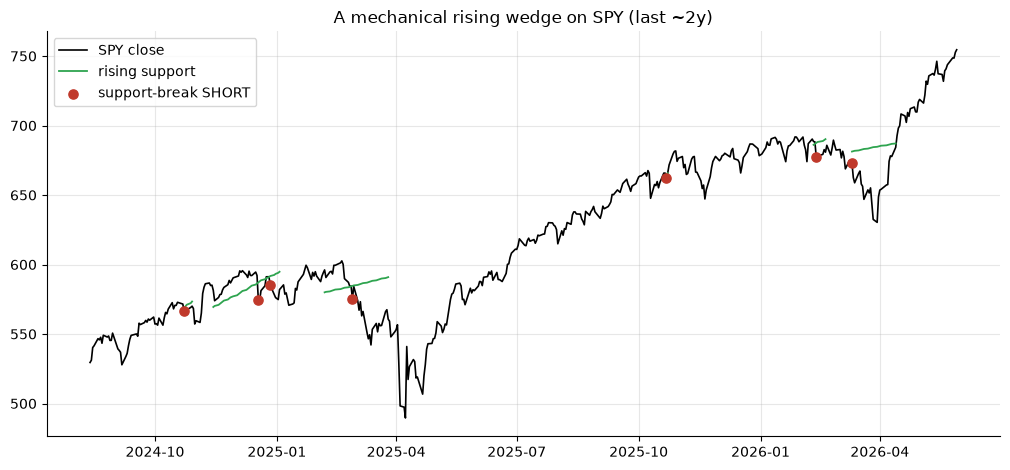

support-break shorts in window: 7


In [2]:
b = load('SPY') if HAVE_REAL else None
if HAVE_REAL:
    cl = b['close']; seg = cl.iloc[-450:]
    sup, act = st.build_wedges(cl, k=R['k'])
    ent = st.wedge_break_entries(cl, k=R['k'])
    ent = ent[ent >= seg.index[0]]
    fig, ax = plt.subplots(figsize=(10.2, 4.8))
    ax.plot(seg.index, seg.values, c='k', lw=1.2, label='SPY close')
    ax.plot(seg.index, sup.reindex(seg.index), c=GREEN, lw=1.3, label='rising support')
    ax.scatter(ent, cl.reindex(ent), c=RED, s=44, zorder=5, label='support-break SHORT')
    ax.set_title('A mechanical rising wedge on SPY (last ~2y)'); ax.legend(loc='upper left')
    plt.tight_layout(); plt.show()
    print('support-break shorts in window:', len(ent))
else:
    print('(no cache — see docs/results.md for the frozen numbers)')

The wedge tracks the rally nicely — *as a description*. The question is whether those red short dots are followed by **falls**. **Let's race the break-down short against random shorts** at four horizons. Red = short the break; grey = short on random days. Bars *below zero* mean the short lost money.

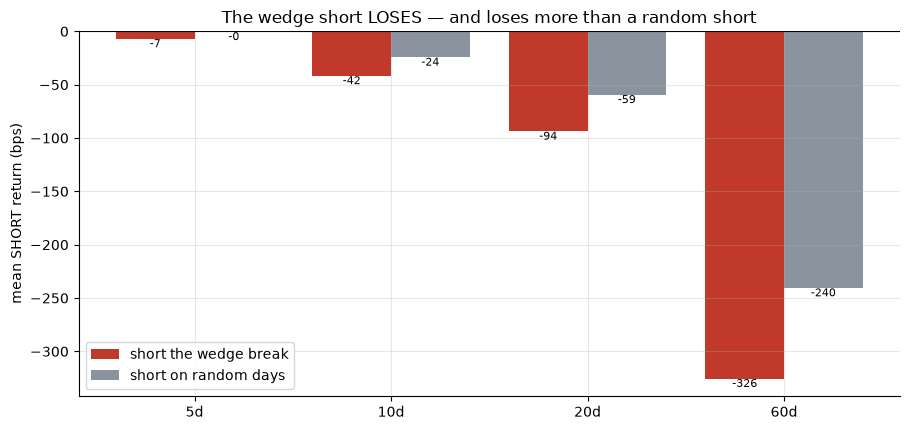

break: [-7, -42, -94, -326]
random: [0, -24, -59, -240]


In [3]:
hs = [5, 10, 20, 60]
if HAVE_REAL:
    brk, rnd = [], []
    for h in hs:
        tt, rr = [], []
        for t in data.DEFAULT_TICKERS:
            c = load(t)['close']
            e = st.wedge_break_entries(c, k=R['k'])
            re = st.random_entries(c, max(len(e),50), k=R['k'], seed=7)
            tt.append(st.forward_returns(c, e, h)); rr.append(st.forward_returns(c, re, h))
        brk.append(np.concatenate(tt).mean()*1e4); rnd.append(np.concatenate(rr).mean()*1e4)
else:
    brk = [R['h5'][2], R['h10'][2], R['h20'][2], R['h60'][2]]
    rnd = [R['h5'][5], R['h10'][5], R['h20'][5], R['h60'][5]]
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.2, 4.4))
ax.bar(x-.2, brk, .4, color=RED, label='short the wedge break')
ax.bar(x+.2, rnd, .4, color=GREY, label='short on random days')
for i,(a,bb) in enumerate(zip(brk,rnd)):
    ax.annotate(f'{a:+.0f}',(i-.2,a),ha='center',va='top',fontsize=8)
    ax.annotate(f'{bb:+.0f}',(i+.2,bb),ha='center',va='top',fontsize=8)
ax.axhline(0, c='k', lw=.8)
ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs]); ax.set_ylabel('mean SHORT return (bps)')
ax.set_title('The wedge short LOSES — and loses more than a random short'); ax.legend()
plt.tight_layout(); plt.show()
print('break:', [round(v) for v in brk]); print('random:', [round(v) for v in rnd])

There's the whole story in one chart. The wedge-break short **loses at every horizon** (**-94 bps** over 20 days) — and the random short loses **less** (**-59 bps**). The supposedly bearish break is followed, on average, by a **relief rally**, not a fall. The pattern doesn't just fail to help — shorting it is *worse* than throwing darts. The 'edge' was the market's upward drift, working against every short.

**One more sanity check.** What if we scramble the wedge's *geometry* — keep the break timing but replace the support line with a random nonsense line? If price really 'respects the rising wedge', the nonsense line should do much worse.

In [4]:
if HAVE_REAL:
    c = load('SPY')['close']
    pl = st.slope_scramble_placebo(c, 20, k=R['k'], n_draws=300, seed=462)
    obs = pl['obs']*1e4; pval = pl['p_value']
else:
    obs = R['placebo'][0]; pval = R['placebo'][1]
print(f'real wedge break-down short (SPY, 20d): {obs:+.1f} bps')
print(f'... and {pval*100:.0f}% of *scrambled-geometry* lines do at least as well (p={pval:.2f}).')
print('=> the rising-wedge geometry is not doing the work.')

real wedge break-down short (SPY, 20d): -100.2 bps
... and 23% of *scrambled-geometry* lines do at least as well (p=0.23).
=> the rising-wedge geometry is not doing the work.


A chunk of the **scrambled** lines match or beat the real one (*p* = 0.25). If price genuinely respected *this specific rising support*, a random scramble would collapse the result. It doesn't — because the result was never about the wedge.

## 5 · The verdict

- **Signal — None.** The break-down short does **not** beat shorting on random days (it's *worse* at every horizon; the break-vs-random difference never clears *t* = 2). The big losses are the market's drift working against a short, not a bearish pattern.
- **Tradability — Mirage.** Nothing to trade: the short loses outright and underperforms a random short — costs only deepen the hole.
- **"Forecasts a downside break"? — Busted.** Scramble the geometry into nonsense and the result barely moves. The wedge doesn't forecast the break.

## 6 · Could you actually trade it?

There's nothing here to trade. Shorting the rising-wedge break loses money outright, and loses *more* than a random short — the pattern actively picks bad moments to be short on an upward-drifting tape. Costs (commissions + spread on every break) push the already-negative result further down. As a forecasting tool the rising wedge doesn't pay; as a drawing tool, it was never meant to be a strategy.

## 7 · Going further 🚪

- **The falling-wedge mirror.** The *falling* wedge is sold as bullish; the desk's [`414-falling-wedge`](../../414-falling-wedge) study tests that twin claim — same machinery, same outcome.
- **Different pivot rules.** Try a wider/narrower fractal window, more touches per line, or hand-anchored wedges — the result is robust: drift in, pattern out.
- **A real positive control.** The quants notebook plants a *genuine* rising-wedge break-down into a synthetic tape and shows the harness banks it (so the null result here isn't a dead detector — it's an honest 'nothing there').

*Think the rising wedge forecasts the break? Show the break-down short beating random shorts at **t ≥ 2** on a real tape — then we'll talk.*